In [100]:
import pandas as pd
import os 
from collections import Counter

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional

def plot_bipo_data(
    data_bipo: Dict[str, Dict[str, Dict[str, Dict[float, float]]]], 
    subplot_titles: Optional[Dict[str, str]] = None,
    main_title: str = "Power-Seeking Evaluation Results"
):
    # 1. Paper-Ready Style
    plt.rcParams.update({
        'font.family': 'serif', 'font.size': 11, 'axes.linewidth': 1.2,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'grid.alpha': 0.3
    })

    unique_names = sorted({n for g in data_bipo.values() for n in g})
    colors = {n: plt.cm.Set2(i % 8) for i, n in enumerate(unique_names)}

    fig, axes = plt.subplots(4, len(data_bipo), figsize=(5.5 * len(data_bipo), 18), squeeze=False)
    # fig.suptitle(main_title, fontsize=16, fontweight='bold', y=1.02)

    for col, (comp_name, data_group) in enumerate(data_bipo.items()):
        if subplot_titles and comp_name in subplot_titles:
            axes[0, col].set_title(subplot_titles[comp_name], pad=20, fontweight='bold')

        steer_data, avg_util_data = [], []

        for name, metrics in data_group.items():
            clr = colors[name]
            # --- ROW 0 & 2: LINE PLOTS ---
            for row, m_key in [(0, "behavior"), (2, "utility")]:
                if m_key in metrics:
                    # Ensure data is sorted by multiplier (x)
                    x_sorted = sorted(metrics[m_key].keys())
                    y_sorted = [metrics[m_key][k] for k in x_sorted]
                    
                    marker = "s" if m_key == "behavior" else "^"
                    axes[row, col].plot(x_sorted, y_sorted, marker=marker, color=clr, label=name, mec='black', lw=2)
                    
                    if m_key == "behavior" and len(x_sorted) > 1:
                        steer_data.append((name, np.polyfit(x_sorted, y_sorted, 1)[0]))
                    if m_key == "utility" and y_sorted:
                        avg_util_data.append((name, np.mean(y_sorted)))

        # --- ROW-SPECIFIC FORMATTING ---
        row_labels = ["Behavior Score", "Steerability", "Utility Score", "Utility Consistency"]
        row_sources = [None, steer_data, None, avg_util_data]

        for row in range(4):
            ax = axes[row, col]
            source = row_sources[row]

            if source is not None:
                source.sort(key=lambda i: i[1], reverse=True)
                for name, val in source:
                    limit = 1.5 if row == 1 else 5.0
                    display_val = np.clip(val, -limit, limit)
                    
                    bar = ax.bar(name, display_val, color=colors[name], edgecolor='black', alpha=0.9)
                    
                    va = 'bottom' if val >= 0 else 'top'
                    # Dynamic offset based on scale
                    offset = 0.05 if row == 3 else 0.02
                    text_y = display_val + (offset if val >= 0 else -offset)
                    
                    ax.text(bar[0].get_x() + bar[0].get_width()/2, text_y, 
                            f'{val:.2f}', ha='center', va=va, fontsize=9, fontweight='bold')
                ax.set_xticks([])
            else:
                ax.legend(loc='upper left', fontsize=8, framealpha=0.5)
                ax.set_xlabel('Multiplier')

            # --- SCALE LOGIC ---
            if row == 1: # Steerability Row (-1.5 to 1.5)
                ax.set_ylim(-1.6, 1.6) 
                ax.set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
                ax.axhline(0, color='black', linewidth=1.0, alpha=0.5) 
            elif row == 3: # Utility Consistency (0 to 5)
                ax.set_ylim(0, 5.5) # Start from 0 so bars aren't cut off
                ax.set_yticks([0, 1, 2, 3, 4, 5])
            else: # Line Plots (1 to 5)
                ax.set_ylim(0.8, 5.5) 
                ax.set_yticks([1, 2, 3, 4, 5])

            ax.set_ylabel(row_labels[row], fontsize=10, fontweight='bold')
            ax.grid(True, ls='--', axis='y' if row % 2 != 0 else 'both')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

In [102]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import SquareTable

# Define the base directory
base_dir = "../reasoning/wealth-seeking/gemma" 

# Define your columns
SCORE_COLUMN = "Score" 
ID_COLUMN = "Question" # Used alongside 'Multiplier' as the composite key
FINAL_RESULT = {
    "Single Layer Ablation": ["gemma3-1b-3","gemma3-1b-13","gemma3-1b-23"],
    "k1 Ablation": ["gemma3-1b-all-exp","gemma3-1b-all-exp-similarity-abs-linear-0_25","gemma3-1b-all-exp-similarity-abs-linear-0_5","gemma3-1b-all-exp-similarity-abs-linear-0_75"],
    "Final Comparison": ["gemma3-1b-all","gemma3-1b-13","gemma3-1b-all-exp-similarity-abs-linear-0_5"],
}
FINAL_SUBDIR =  FINAL_RESULT['Final Comparison']+FINAL_RESULT['k1 Ablation']+FINAL_RESULT['Single Layer Ablation']

def load_agg_data(base_path):
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping

if __name__ == "__main__":
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if subdir_name in FINAL_SUBDIR:
            if 'behavior' in subdir_data:
                b_df = subdir_data['behavior']
                if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                    # Find rows where score is 0
                    bad_mask = b_df[SCORE_COLUMN] == 0
                    # Zip the question and multiplier together into tuples and add to our set
                    bad_tuples = set(zip(b_df.loc[bad_mask, ID_COLUMN], b_df.loc[bad_mask, 'Multiplier']))
                    global_bad_behavior_keys.update(bad_tuples)
                    
            if 'utility' in subdir_data:
                u_df = subdir_data['utility']
                if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                    # Find rows where score is 0
                    bad_mask = u_df[SCORE_COLUMN] == 0
                    # Zip the question and multiplier together into tuples and add to our set
                    bad_tuples = set(zip(u_df.loc[bad_mask, ID_COLUMN], u_df.loc[bad_mask, 'Multiplier']))
                    global_bad_utility_keys.update(bad_tuples)

    behavior_multiplier_counts = Counter(mult for _, mult in global_bad_behavior_keys)
    utility_multiplier_counts = Counter(mult for _, mult in global_bad_utility_keys)
    print(f"Found {len(global_bad_behavior_keys)} unique pairs to drop globally in Behavior.")
    for mult, count in sorted(behavior_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    print("-" * 30)

    # Print Utility counts
    print(f"Found {len(global_bad_utility_keys)} unique pairs to drop globally in Utility.")
    for mult, count in sorted(utility_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        
        # Calculate averages for Behavior
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([b_df[ID_COLUMN], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_b_df = b_df[~mask]
                # b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg

                clean_b_df = b_df[b_df[SCORE_COLUMN] != 0]
                b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        # Calculate averages for Utility
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([u_df[ID_COLUMN], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_u_df = u_df[~mask]
                # u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                clean_u_df = u_df[u_df[SCORE_COLUMN] != 0]
                u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg

    for key, card in FINAL_RESULT.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

# Define your list of baseline directory names here
baseline_subdirs = ["gemma3-1b-13", "gemma3-1b-all"] # Update with your actual folder names

# Dictionary to hold nested results: {baseline: {mode: {comparison_subdir: results}}}
results_mcnemar = {}

for baseline_name in baseline_subdirs:
    results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
    
    for mode in ['behavior', 'utility']:
        # Use the appropriate global bad keys for the current mode
        bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
        
        # Ensure the baseline actually exists and has data for this mode
        if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
            print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
            continue
            
        # 1. Prepare the Baseline Data
        base_df = gemma_data[baseline_name][mode]
        base_keys = pd.MultiIndex.from_arrays([base_df[ID_COLUMN], base_df['Multiplier']])
        clean_base = base_df[~base_keys.isin(bad_keys)]
        
        # 2. Iterate through all other subdirectories to compare against the current baseline
        for subdir_name, subdir_data in gemma_data.items():
            if subdir_name == baseline_name:
                continue # Skip comparing the baseline to itself
                
            if mode in subdir_data:
                comp_df = subdir_data[mode]
                
                # Clean the comparison data
                comp_keys = pd.MultiIndex.from_arrays([comp_df[ID_COLUMN], comp_df['Multiplier']])
                clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                
                # 3. Merge Baseline and Comparison on the composite key
                merged = pd.merge(
                    clean_base[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    clean_comp[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    on=[ID_COLUMN, 'Multiplier'],
                    suffixes=('_base', '_comp')
                )
                
                if not merged.empty:
                    # 4. Create Contingency Table
                    contingency_table = pd.crosstab(
                        merged[f'{SCORE_COLUMN}_base'], 
                        merged[f'{SCORE_COLUMN}_comp']
                    )
                    
                    # Force the table to be square (McNemar-Bowker requirement)
                    all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                    contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                    
                    # 5. Perform the Test (requires at least a 2x2 table)
                    if contingency_table.shape[0] > 1: 
                        st = SquareTable(contingency_table.values)
                        test_result = st.symmetry()
                        
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "statistic": test_result.statistic,
                            "p_value": test_result.pvalue,
                            "n": len(merged)
                        }
                    else:
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "error": "Not enough variance (1x1 table)", 
                            "n": len(merged)
                        }

# --- Print Results ---
print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
for baseline_name, modes in results_mcnemar.items():
    print(f"\n==================================================")
    print(f"BASELINE: {baseline_name}")
    print(f"==================================================")
    
    for mode in ['behavior', 'utility']:
        print(f"\n-- {mode.upper()} --")
        if not modes[mode]:
            print("  No comparisons made.")
        
        for subdir, res in modes[mode].items():
            if "error" in res:
                print(f"  vs {subdir}: {res['error']} (n={res['n']})")
            else:
                sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                if subdir in FINAL_SUBDIR:
                    print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

Found 559 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 101 pairs
  - Multiplier -1.5: 112 pairs
  - Multiplier -1.0: 82 pairs
  - Multiplier -0.5: 95 pairs
  - Multiplier 0.0: 7 pairs
  - Multiplier 0.5: 52 pairs
  - Multiplier 1.0: 30 pairs
  - Multiplier 1.5: 38 pairs
  - Multiplier 2.0: 42 pairs
------------------------------
Found 344 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 53 pairs
  - Multiplier -1.5: 48 pairs
  - Multiplier -1.0: 36 pairs
  - Multiplier -0.5: 32 pairs
  - Multiplier 0.0: 4 pairs
  - Multiplier 0.5: 37 pairs
  - Multiplier 1.0: 39 pairs
  - Multiplier 1.5: 49 pairs
  - Multiplier 2.0: 46 pairs

Single Layer Ablation
=== BEHAVIOR AVERAGE SCORES ===
gemma3-1b-13: {-2.0: 2.4685714285714284, -1.5: 2.5027624309392267, -1.0: 2.7955801104972378, -0.5: 2.754491017964072, 0.0: 2.7512953367875648, 0.5: 2.7905759162303663, 1.0: 2.948717948717949, 1.5: 3.020618556701031, 2.0: 3.139896373056995}
gemma3-1b-3: {-2.0: 2.6927374301675977,

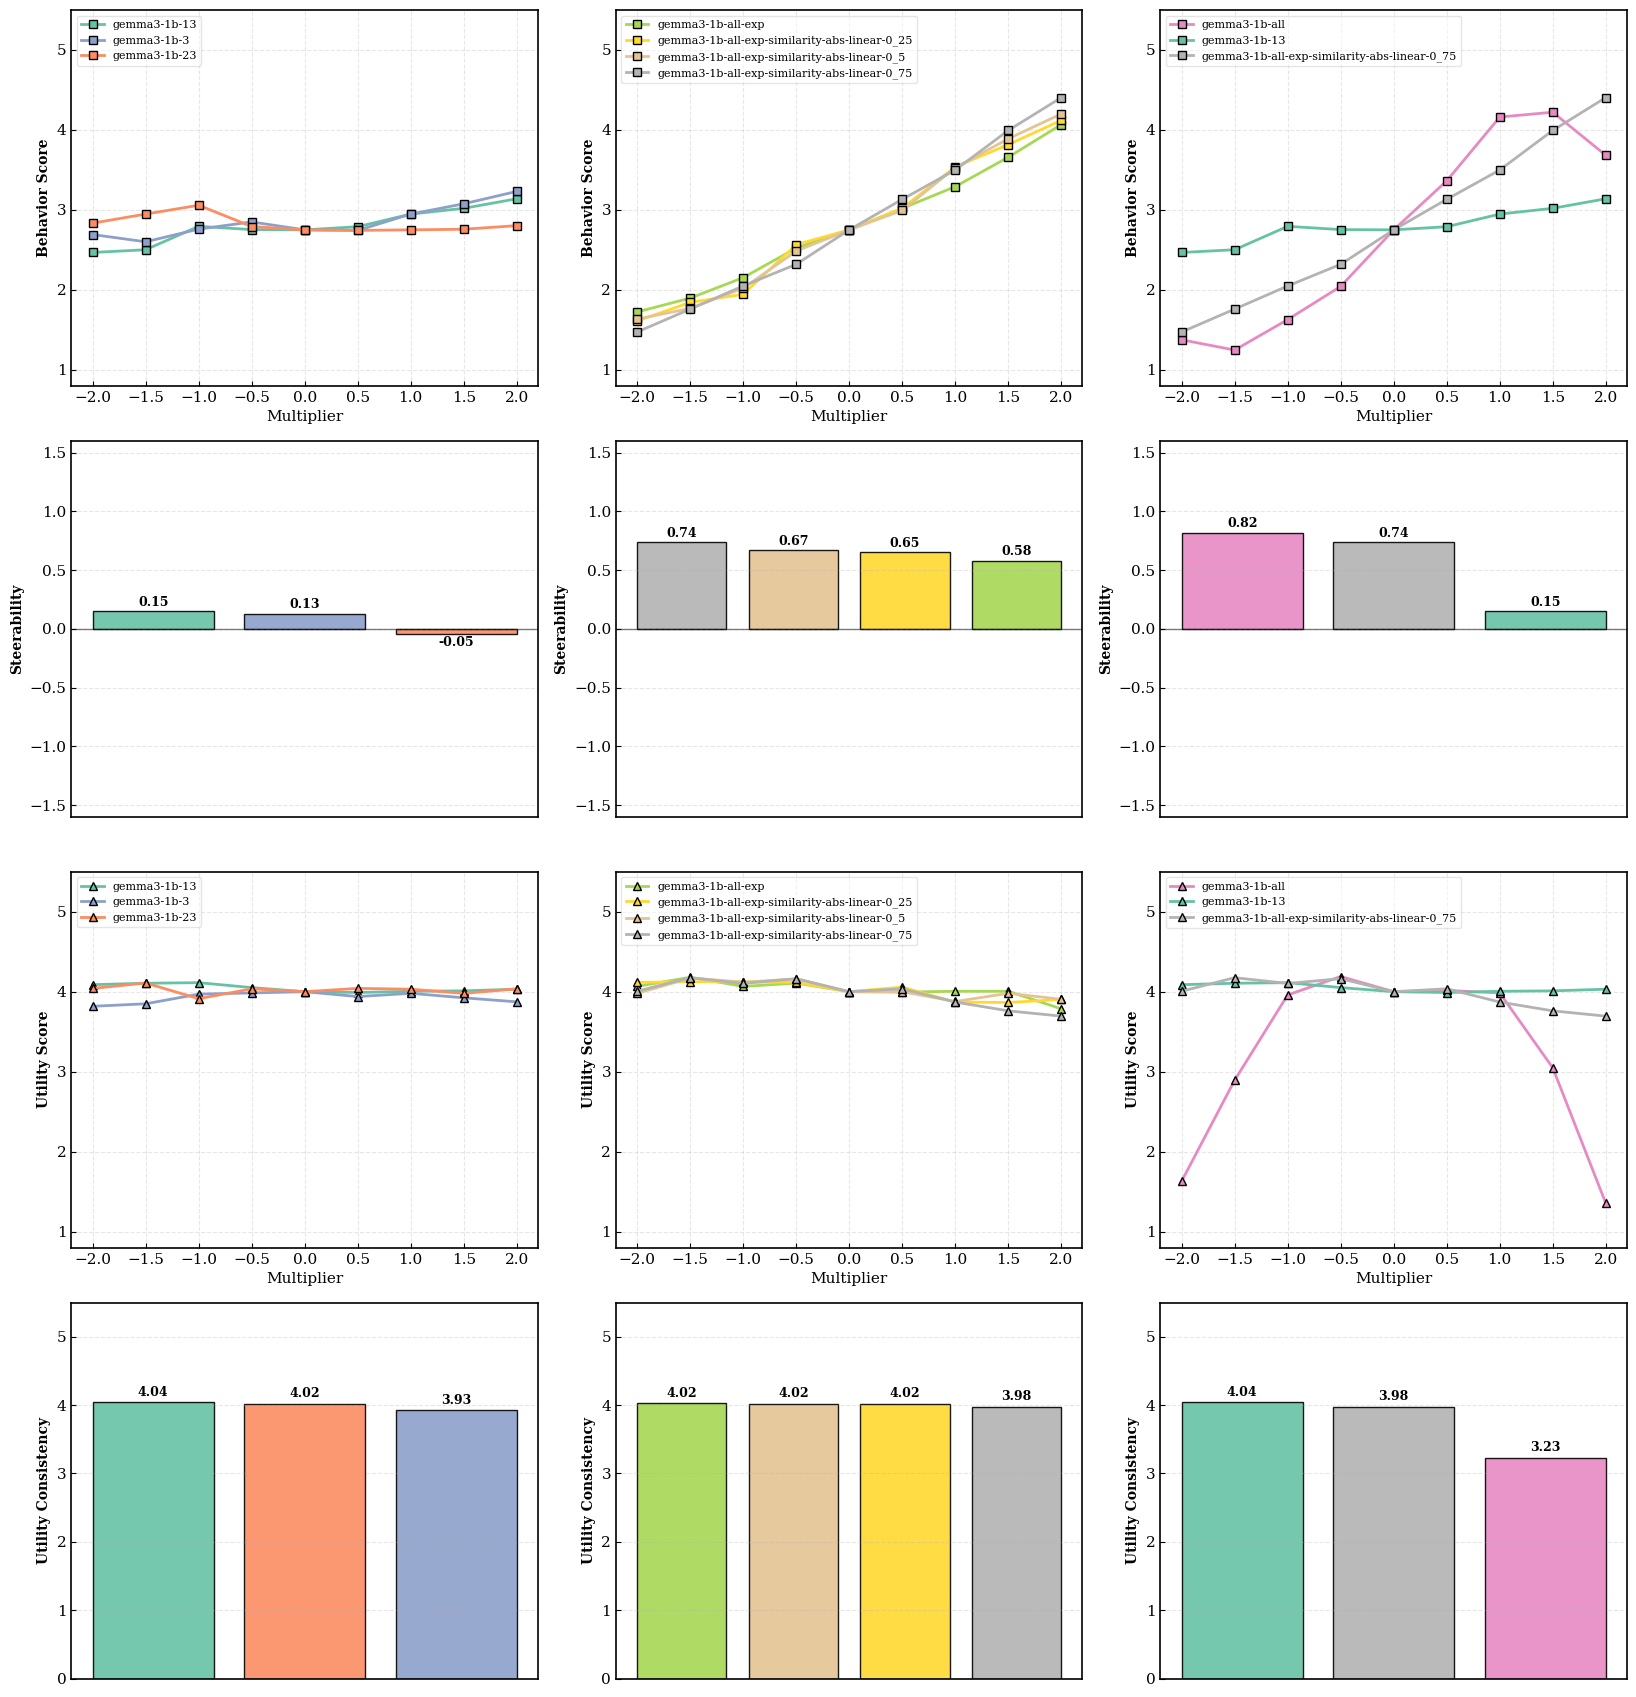

In [103]:
data_gemma = {
    "Single Layer Ablation": {
        "gemma3-1b-13": {
            "behavior": {-2.0: 2.4685714285714284, -1.5: 2.5027624309392267, -1.0: 2.7955801104972378, -0.5: 2.754491017964072, 0.0: 2.7512953367875648, 0.5: 2.7905759162303663, 1.0: 2.948717948717949, 1.5: 3.020618556701031, 2.0: 3.139896373056995},
            "utility":  {-2.0: 4.087628865979381, -1.5: 4.105527638190955, -1.0: 4.112820512820512, -0.5: 4.051282051282051, 0.0: 4.0, 0.5: 3.989795918367347, 1.0: 4.005102040816326, 1.5: 4.010416666666667, 2.0: 4.030927835051546}
        },
        "gemma3-1b-3": {
            "behavior": {-2.0: 2.6927374301675977, -1.5: 2.602272727272727, -1.0: 2.7606382978723403, -0.5: 2.8505747126436782, 0.0: 2.7512953367875648, 0.5: 2.7447916666666665, 1.0: 2.948717948717949, 1.5: 3.077319587628866, 2.0: 3.231958762886598},
            "utility": {-2.0: 3.8177083333333335, -1.5: 3.8484848484848486, -1.0: 3.969543147208122, -0.5: 3.9844559585492227, 0.0: 4.0, 0.5: 3.9390862944162435, 1.0: 3.979591836734694, 1.5: 3.923469387755102, 2.0: 3.873015873015873}
        },
        "gemma3-1b-23": {
            "behavior": {-2.0: 2.835227272727273, -1.5: 2.9485714285714284, -1.0: 3.0591397849462365, -0.5: 2.793103448275862, 0.0: 2.7512953367875648, 0.5: 2.7447916666666665, 1.0: 2.751269035532995, 1.5: 2.758974358974359, 2.0: 2.804123711340206},
            "utility": {-2.0: 4.040816326530612, -1.5: 4.108808290155441, -1.0: 3.9123711340206184, -0.5: 4.035532994923858, 0.0: 4.0, 0.5: 4.041450777202073, 1.0: 4.030927835051546, 1.5: 3.979057591623037, 2.0: 4.036082474226804}
        }
    },
    "k1 Ablation": {
        "gemma3-1b-all-exp": {
            "behavior":  {-2.0: 1.7247191011235956, -1.5: 1.8977272727272727, -1.0: 2.1538461538461537, -0.5: 2.5229885057471266, 0.0: 2.7512953367875648, 0.5: 3.020618556701031, 1.0: 3.2916666666666665, 1.5: 3.6597938144329896, 2.0: 4.0680628272251305},
            "utility": {-2.0: 4.066666666666666, -1.5: 4.1798941798941796, -1.0: 4.065989847715736, -0.5: 4.107142857142857, 0.0: 4.0, 0.5: 3.9947916666666665, 1.0: 4.005208333333333, 1.5: 4.005128205128205, 2.0: 3.7853403141361257}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_25": {
            "behavior":{-2.0: 1.6114285714285714, -1.5: 1.8448275862068966, -1.0: 1.945945945945946, -0.5: 2.5668449197860963, 0.0: 2.7512953367875648, 0.5: 3.0211640211640214, 1.0: 3.5392670157068062, 1.5: 3.816753926701571, 2.0: 4.12041884816754},
            "utility": {-2.0: 4.116402116402116, -1.5: 4.124352331606218, -1.0: 4.123076923076923, -0.5: 4.11734693877551, 0.0: 4.0, 0.5: 4.057291666666667, 1.0: 3.8697916666666665, 1.5: 3.865284974093264, 2.0: 3.9025641025641025}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.6358381502890174, -1.5: 1.7696629213483146, -1.0: 2.021978021978022, -0.5: 2.4860335195530725, 0.0: 2.7512953367875648, 0.5: 2.9947916666666665, 1.0: 3.5287958115183247, 1.5: 3.890625, 2.0: 4.201030927835052},
            "utility": {-2.0: 3.9788359788359786, -1.5: 4.171122994652406, -1.0: 4.119791666666667, -0.5: 4.158163265306122, 0.0: 4.0, 0.5: 4.0, 1.0: 3.877551020408163, 1.5: 3.979381443298969, 2.0: 3.905263157894737}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.4739884393063585, -1.5: 1.7608695652173914, -1.0: 2.0494505494505493, -0.5: 2.3206521739130435, 0.0: 2.7512953367875648, 0.5: 3.132978723404255, 1.0: 3.5, 1.5: 3.994708994708995, 2.0: 4.405263157894737},
            "utility": {-2.0: 4.005263157894737, -1.5: 4.175257731958763, -1.0: 4.102564102564102, -0.5: 4.163265306122449, 0.0: 4.0, 0.5: 4.035897435897436, 1.0: 3.8704663212435233, 1.5: 3.7604166666666665, 2.0: 3.694300518134715}
        },
    },
    "Final Comparison": {
        "gemma3-1b-all": {
            "behavior": {-2.0: 1.3771428571428572, -1.5: 1.2486187845303867, -1.0: 1.6294117647058823, -0.5: 2.044943820224719, 0.0: 2.7512953367875648, 0.5: 3.364102564102564, 1.0: 4.161616161616162, 1.5: 4.222222222222222, 2.0: 3.6834170854271355},
            "utility": {-2.0: 1.6302083333333333, -1.5: 2.893048128342246, -1.0: 3.9591836734693877, -0.5: 4.18974358974359, 0.0: 4.0, 0.5: 4.015625, 1.0: 3.9846153846153847, 1.5: 3.0476190476190474, 2.0: 1.3541666666666667}
        },
        "gemma3-1b-13": {
            "behavior": {-2.0: 2.4685714285714284, -1.5: 2.5027624309392267, -1.0: 2.7955801104972378, -0.5: 2.754491017964072, 0.0: 2.7512953367875648, 0.5: 2.7905759162303663, 1.0: 2.948717948717949, 1.5: 3.020618556701031, 2.0: 3.139896373056995},
            "utility":  {-2.0: 4.087628865979381, -1.5: 4.105527638190955, -1.0: 4.112820512820512, -0.5: 4.051282051282051, 0.0: 4.0, 0.5: 3.989795918367347, 1.0: 4.005102040816326, 1.5: 4.010416666666667, 2.0: 4.030927835051546}
        },
        "gemma3-1b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.4739884393063585, -1.5: 1.7608695652173914, -1.0: 2.0494505494505493, -0.5: 2.3206521739130435, 0.0: 2.7512953367875648, 0.5: 3.132978723404255, 1.0: 3.5, 1.5: 3.994708994708995, 2.0: 4.405263157894737},
            "utility": {-2.0: 4.005263157894737, -1.5: 4.175257731958763, -1.0: 4.102564102564102, -0.5: 4.163265306122449, 0.0: 4.0, 0.5: 4.035897435897436, 1.0: 3.8704663212435233, 1.5: 3.7604166666666665, 2.0: 3.694300518134715}
        }
    }
}
plot_bipo_data(data_gemma)

In [104]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import SquareTable

# Define the base directory
base_dir = "../reasoning/wealth-seeking/llama" 

# Define your columns
SCORE_COLUMN = "Score" 
ID_COLUMN = "Question" # Used alongside 'Multiplier' as the composite key

def load_agg_data(base_path):
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping

if __name__ == "__main__":
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Find rows where score is 0
                bad_mask = b_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(b_df.loc[bad_mask, ID_COLUMN], b_df.loc[bad_mask, 'Multiplier']))
                global_bad_behavior_keys.update(bad_tuples)
                
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Find rows where score is 0
                bad_mask = u_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(u_df.loc[bad_mask, ID_COLUMN], u_df.loc[bad_mask, 'Multiplier']))
                global_bad_utility_keys.update(bad_tuples)

    print(f"Found {len(global_bad_behavior_keys)} unique (Question, Multiplier) pairs to drop globally in Behavior.")
    print(f"Found {len(global_bad_utility_keys)} unique (Question, Multiplier) pairs to drop globally in Utility.")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        
        # Calculate averages for Behavior
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([b_df[ID_COLUMN], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_b_df = b_df[~mask]
                # b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg

                clean_b_df = b_df[b_df[SCORE_COLUMN] != 0]
                b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        # Calculate averages for Utility
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([u_df[ID_COLUMN], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_u_df = u_df[~mask]
                # u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                clean_u_df = u_df[u_df[SCORE_COLUMN] != 0]
                u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg
                
    FINAL_RESULT = {
        "Single Layer Ablation": ["llama3-1-8b-6","llama3-1-8b-16","llama3-1-8b-26"],
        "k1 Ablation": ["llama3-1-8b-all-exp","llama3-1-8b-all-exp-similarity-abs-linear-0_25","llama3-1-8b-all-exp-similarity-abs-linear-0_5","llama3-1-8b-all-exp-similarity-abs-linear-0_75"],
        "Final Comparison": ["llama3-1-8b-16","llama3-1-8b-all","llama3-1-8b-all-exp-similarity-abs-linear-0_75"],
    }
    FINAL_SUBDIR =  FINAL_RESULT['Single Layer Ablation']+FINAL_RESULT['Final Comparison']+FINAL_RESULT['k1 Ablation']

    for key, card in FINAL_RESULT.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

# Define your list of baseline directory names here
baseline_subdirs = ["llama3-1-8b-16", "llama3-1-8b-all"] # Update with your actual folder names

# Dictionary to hold nested results: {baseline: {mode: {comparison_subdir: results}}}
results_mcnemar = {}

for baseline_name in baseline_subdirs:
    results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
    
    for mode in ['behavior', 'utility']:
        # Use the appropriate global bad keys for the current mode
        bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
        
        # Ensure the baseline actually exists and has data for this mode
        if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
            print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
            continue
            
        # 1. Prepare the Baseline Data
        base_df = gemma_data[baseline_name][mode]
        base_keys = pd.MultiIndex.from_arrays([base_df[ID_COLUMN], base_df['Multiplier']])
        clean_base = base_df[~base_keys.isin(bad_keys)]
        
        # 2. Iterate through all other subdirectories to compare against the current baseline
        for subdir_name, subdir_data in gemma_data.items():
            if subdir_name == baseline_name:
                continue # Skip comparing the baseline to itself
                
            if mode in subdir_data:
                comp_df = subdir_data[mode]
                
                # Clean the comparison data
                comp_keys = pd.MultiIndex.from_arrays([comp_df[ID_COLUMN], comp_df['Multiplier']])
                clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                
                # 3. Merge Baseline and Comparison on the composite key
                merged = pd.merge(
                    clean_base[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    clean_comp[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    on=[ID_COLUMN, 'Multiplier'],
                    suffixes=('_base', '_comp')
                )
                
                if not merged.empty:
                    # 4. Create Contingency Table
                    contingency_table = pd.crosstab(
                        merged[f'{SCORE_COLUMN}_base'], 
                        merged[f'{SCORE_COLUMN}_comp']
                    )
                    
                    # Force the table to be square (McNemar-Bowker requirement)
                    all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                    contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                    
                    # 5. Perform the Test (requires at least a 2x2 table)
                    if contingency_table.shape[0] > 1: 
                        st = SquareTable(contingency_table.values)
                        test_result = st.symmetry()
                        
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "statistic": test_result.statistic,
                            "p_value": test_result.pvalue,
                            "n": len(merged)
                        }
                    else:
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "error": "Not enough variance (1x1 table)", 
                            "n": len(merged)
                        }

# --- Print Results ---
print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
for baseline_name, modes in results_mcnemar.items():
    print(f"\n==================================================")
    print(f"BASELINE: {baseline_name}")
    print(f"==================================================")
    
    for mode in ['behavior', 'utility']:
        print(f"\n-- {mode.upper()} --")
        if not modes[mode]:
            print("  No comparisons made.")
        
        for subdir, res in modes[mode].items():
            if "error" in res:
                print(f"  vs {subdir}: {res['error']} (n={res['n']})")
            else:
                sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

Found 380 unique (Question, Multiplier) pairs to drop globally in Behavior.
Found 148 unique (Question, Multiplier) pairs to drop globally in Utility.

Single Layer Ablation
=== BEHAVIOR AVERAGE SCORES ===
llama3-1-8b-16: {-2.0: 2.1693121693121693, -1.5: 2.232804232804233, -1.0: 2.2857142857142856, -0.5: 2.3262032085561497, 0.0: 2.3794871794871795, 0.5: 2.1818181818181817, 1.0: 2.393939393939394, 1.5: 2.3025641025641024, 2.0: 2.348717948717949}
llama3-1-8b-26: {-2.0: 2.4078212290502794, -1.5: 2.4945054945054945, -1.0: 2.308988764044944, -0.5: 2.3444444444444446, 0.0: 2.3794871794871795, 0.5: 2.312820512820513, 1.0: 2.2462311557788945, 1.5: 2.2142857142857144, 2.0: 2.3096446700507616}
llama3-1-8b-6: {-2.0: 2.3076923076923075, -1.5: 2.3502824858757063, -1.0: 2.5, -0.5: 2.3783783783783785, 0.0: 2.3794871794871795, 0.5: 2.241025641025641, 1.0: 2.1472081218274113, 1.5: 2.0153061224489797, 2.0: 1.9743589743589745}

=== UTILITY AVERAGE SCORES ===
llama3-1-8b-16: {-2.0: 4.015151515151516, -1.5

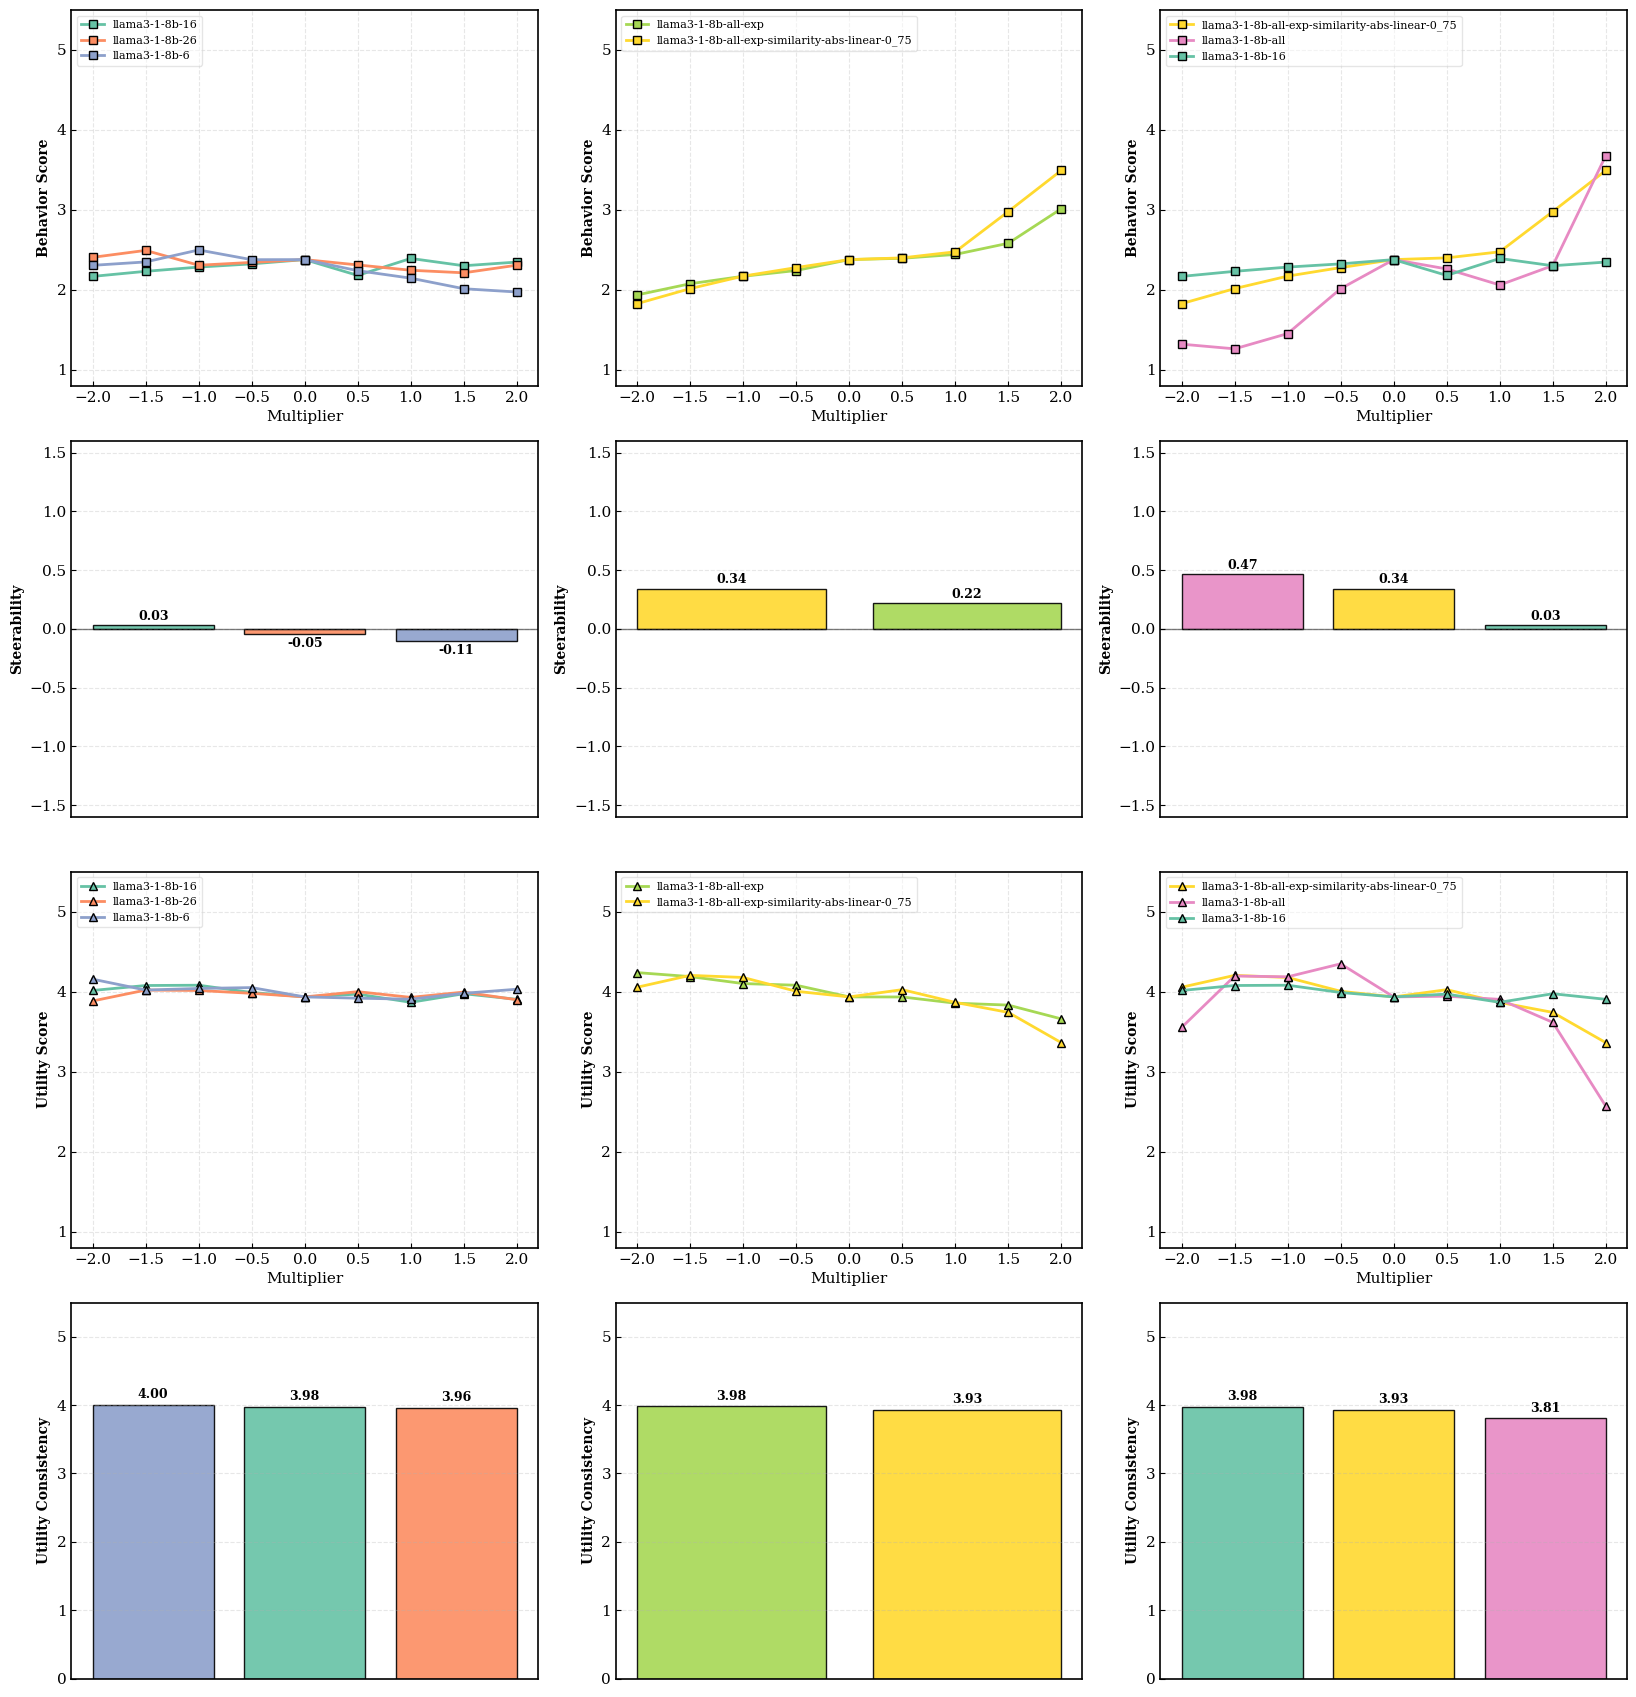

In [105]:
data_llama = {
    "Single Layer Ablation": {
        "llama3-1-8b-16": {
            "behavior": {-2.0: 2.1693121693121693, -1.5: 2.232804232804233, -1.0: 2.2857142857142856, -0.5: 2.3262032085561497, 0.0: 2.3794871794871795, 0.5: 2.1818181818181817, 1.0: 2.393939393939394, 1.5: 2.3025641025641024, 2.0: 2.348717948717949},
            "utility": {-2.0: 4.015151515151516, -1.5: 4.077319587628866, -1.0: 4.08080808080808, -0.5: 3.989795918367347, 0.0: 3.9346733668341707, 0.5: 3.9696969696969697, 1.0: 3.86734693877551, 1.5: 3.9744897959183674, 2.0: 3.9045226130653266}
        },
        "llama3-1-8b-26": {
            "behavior": {-2.0: 2.4078212290502794, -1.5: 2.4945054945054945, -1.0: 2.308988764044944, -0.5: 2.3444444444444446, 0.0: 2.3794871794871795, 0.5: 2.312820512820513, 1.0: 2.2462311557788945, 1.5: 2.2142857142857144, 2.0: 2.3096446700507616},
            "utility": {-2.0: 3.8838383838383836, -1.5: 4.020304568527918, -1.0: 4.015075376884422, -0.5: 3.979591836734694, 0.0: 3.9346733668341707, 0.5: 4.0, 1.0: 3.9289340101522843, 1.5: 3.9949748743718594, 2.0: 3.898989898989899}
        },
        "llama3-1-8b-6": {
            "behavior": {-2.0: 2.3076923076923075, -1.5: 2.3502824858757063, -1.0: 2.5, -0.5: 2.3783783783783785, 0.0: 2.3794871794871795, 0.5: 2.241025641025641, 1.0: 2.1472081218274113, 1.5: 2.0153061224489797, 2.0: 1.9743589743589745},
            "utility": {-2.0: 4.156565656565657, -1.5: 4.020408163265306, -1.0: 4.040404040404041, -0.5: 4.051282051282051, 0.0: 3.9346733668341707, 0.5: 3.918781725888325, 1.0: 3.90625, 1.5: 3.9797979797979797, 2.0: 4.030612244897959}
        }
    },
    "k1 Ablation": {
        "llama3-1-8b-all-exp": {
            "behavior": {-2.0: 1.9378531073446328, -1.5: 2.077777777777778, -1.0: 2.171122994652406, -0.5: 2.2430939226519335, 0.0: 2.3794871794871795, 0.5: 2.3959390862944163, 1.0: 2.443877551020408, 1.5: 2.583756345177665, 2.0: 3.0153846153846153},
            "utility": {-2.0: 4.238578680203045, -1.5: 4.188775510204081, -1.0: 4.101522842639594, -0.5: 4.08080808080808, 0.0: 3.9346733668341707, 0.5: 3.934010152284264, 1.0: 3.8564102564102565, 1.5: 3.83248730964467, 2.0: 3.6598984771573604}
        },
        "llama3-1-8b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.828729281767956, -1.5: 2.016759776536313, -1.0: 2.172972972972973, -0.5: 2.2795698924731185, 0.0: 2.3794871794871795, 0.5: 2.401015228426396, 1.0: 2.476923076923077, 1.5: 2.979899497487437, 2.0: 3.4947368421052634},
            "utility": {-2.0: 4.055555555555555, -1.5: 4.204081632653061, -1.0: 4.177664974619289, -0.5: 4.005025125628141, 0.0: 3.9346733668341707, 0.5: 4.025380710659898, 1.0: 3.865979381443299, 1.5: 3.7411167512690353, 2.0: 3.3626943005181347}
        }
    },
    "Final Comparison": {
        "llama3-1-8b-all-exp-similarity-abs-linear-0_75": {
            "behavior": {-2.0: 1.828729281767956, -1.5: 2.016759776536313, -1.0: 2.172972972972973, -0.5: 2.2795698924731185, 0.0: 2.3794871794871795, 0.5: 2.401015228426396, 1.0: 2.476923076923077, 1.5: 2.979899497487437, 2.0: 3.4947368421052634},
            "utility": {-2.0: 4.055555555555555, -1.5: 4.204081632653061, -1.0: 4.177664974619289, -0.5: 4.005025125628141, 0.0: 3.9346733668341707, 0.5: 4.025380710659898, 1.0: 3.865979381443299, 1.5: 3.7411167512690353, 2.0: 3.3626943005181347}
        },
        "llama3-1-8b-all": {
            "behavior": {-2.0: 1.3222222222222222, -1.5: 1.2637362637362637, -1.0: 1.4545454545454546, -0.5: 2.016216216216216, 0.0: 2.3794871794871795, 0.5: 2.2626262626262625, 1.0: 2.062176165803109, 1.5: 2.304123711340206, 2.0: 3.679144385026738},
            "utility": {-2.0: 3.553299492385787, -1.5: 4.195876288659794, -1.0: 4.185929648241206, -0.5: 4.348484848484849, 0.0: 3.9346733668341707, 0.5: 3.943589743589744, 1.0: 3.904040404040404, 1.5: 3.616580310880829, 2.0: 2.568421052631579}
        },
        "llama3-1-8b-16": {
            "behavior": {-2.0: 2.1693121693121693, -1.5: 2.232804232804233, -1.0: 2.2857142857142856, -0.5: 2.3262032085561497, 0.0: 2.3794871794871795, 0.5: 2.1818181818181817, 1.0: 2.393939393939394, 1.5: 2.3025641025641024, 2.0: 2.348717948717949},
            "utility": {-2.0: 4.015151515151516, -1.5: 4.077319587628866, -1.0: 4.08080808080808, -0.5: 3.989795918367347, 0.0: 3.9346733668341707, 0.5: 3.9696969696969697, 1.0: 3.86734693877551, 1.5: 3.9744897959183674, 2.0: 3.9045226130653266}
        }
    }
}
plot_bipo_data(data_llama)

In [106]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import SquareTable

# Define the base directory
base_dir = "../reasoning/wealth-seeking/mistral" 

# Define your columns
SCORE_COLUMN = "Score" 
ID_COLUMN = "Question" # Used alongside 'Multiplier' as the composite key

def load_agg_data(base_path):
    data_mapping = {}
    if not os.path.exists(base_path):
        print(f"Error: Directory '{base_path}' not found.")
        return data_mapping

    for subdir_name in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir_name)
        if os.path.isdir(subdir_path):
            behavior_file = os.path.join(subdir_path, f"{subdir_name}_behavior_agg.csv")
            utility_file = os.path.join(subdir_path, f"{subdir_name}_utility_agg.csv")
            
            subdir_data = {}
            if os.path.exists(behavior_file):
                subdir_data['behavior'] = pd.read_csv(behavior_file)
            if os.path.exists(utility_file):
                subdir_data['utility'] = pd.read_csv(utility_file)
            
            if subdir_data:
                data_mapping[subdir_name] = subdir_data

    return data_mapping

if __name__ == "__main__":
    gemma_data = load_agg_data(base_dir)
    
    # --- PASS 1: Collect global bad composite keys: (Question, Multiplier) ---
    global_bad_behavior_keys = set()
    global_bad_utility_keys = set()
    
    for subdir_name, subdir_data in gemma_data.items():
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Find rows where score is 0
                bad_mask = b_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(b_df.loc[bad_mask, ID_COLUMN], b_df.loc[bad_mask, 'Multiplier']))
                global_bad_behavior_keys.update(bad_tuples)
                
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Find rows where score is 0
                bad_mask = u_df[SCORE_COLUMN] == 0
                # Zip the question and multiplier together into tuples and add to our set
                bad_tuples = set(zip(u_df.loc[bad_mask, ID_COLUMN], u_df.loc[bad_mask, 'Multiplier']))
                global_bad_utility_keys.update(bad_tuples)

    behavior_multiplier_counts = Counter(mult for _, mult in global_bad_behavior_keys)
    utility_multiplier_counts = Counter(mult for _, mult in global_bad_utility_keys)

    # Print Behavior counts
    print(f"Found {len(global_bad_behavior_keys)} unique pairs to drop globally in Behavior.")
    for mult, count in sorted(behavior_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    print("-" * 30)

    # Print Utility counts
    print(f"Found {len(global_bad_utility_keys)} unique pairs to drop globally in Utility.")
    for mult, count in sorted(utility_multiplier_counts.items()):
        print(f"  - Multiplier {mult}: {count} pairs")

    # --- PASS 2: Filter by composite key and calculate means ---
    behavior_avg_scores = {}
    utility_avg_scores = {}
    
    for subdir_name, subdir_data in gemma_data.items():
        
        # Calculate averages for Behavior
        if 'behavior' in subdir_data:
            b_df = subdir_data['behavior']
            if SCORE_COLUMN in b_df.columns and ID_COLUMN in b_df.columns and 'Multiplier' in b_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([b_df[ID_COLUMN], b_df['Multiplier']])
                mask = current_keys.isin(global_bad_behavior_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_b_df = b_df[~mask]
                # b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # behavior_avg_scores[subdir_name] = b_avg

                clean_b_df = b_df[b_df[SCORE_COLUMN] != 0]
                b_avg = clean_b_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                behavior_avg_scores[subdir_name] = b_avg

        # Calculate averages for Utility
        if 'utility' in subdir_data:
            u_df = subdir_data['utility']
            if SCORE_COLUMN in u_df.columns and ID_COLUMN in u_df.columns and 'Multiplier' in u_df.columns:
                # Create a multi-index from the current dataframe to check against our bad keys
                current_keys = pd.MultiIndex.from_arrays([u_df[ID_COLUMN], u_df['Multiplier']])
                mask = current_keys.isin(global_bad_utility_keys)
                
                # Keep only rows that are NOT in the bad keys mask
                # clean_u_df = u_df[~mask]
                # u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                # utility_avg_scores[subdir_name] = u_avg

                clean_u_df = u_df[u_df[SCORE_COLUMN] != 0]
                u_avg = clean_u_df.groupby('Multiplier')[SCORE_COLUMN].mean().to_dict()
                utility_avg_scores[subdir_name] = u_avg

    FINAL_RESULT = {
        "Single Layer Ablation": ["mistral-7b-6","mistral-7b-16","mistral-7b-26"],
        "k1 Ablation": ["mistral-7b-all-exp","mistral-7b-all-exp-similarity-abs-linear-0_25","mistral-7b-all-exp-similarity-abs-linear-0_5","mistral-7b-all-exp-similarity-abs-linear-0_75"],
        "Multi Layer Ablation": ["mistral-7b-6","mistral-7b-all","mistral-7b-all-exp-similarity-abs-linear-0_5"],
    }
    FINAL_SUBDIR =  FINAL_RESULT['Single Layer Ablation']+FINAL_RESULT['Multi Layer Ablation']+FINAL_RESULT['k1 Ablation']

    for key, card in FINAL_RESULT.items():
        print(f"\n{key}")
        print("=== BEHAVIOR AVERAGE SCORES ===")
        for subdir, scores in behavior_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")
            
        print("\n=== UTILITY AVERAGE SCORES ===")
        for subdir, scores in utility_avg_scores.items():
            if subdir in card:
                print(f"{subdir}: {scores}")

# Define your list of baseline directory names here
baseline_subdirs = ["mistral-7b-6", "mistral-7b-all"] # Update with your actual folder names

# Dictionary to hold nested results: {baseline: {mode: {comparison_subdir: results}}}
results_mcnemar = {}

for baseline_name in baseline_subdirs:
    results_mcnemar[baseline_name] = {'behavior': {}, 'utility': {}}
    
    for mode in ['behavior', 'utility']:
        # Use the appropriate global bad keys for the current mode
        bad_keys = global_bad_behavior_keys if mode == 'behavior' else global_bad_utility_keys
        
        # Ensure the baseline actually exists and has data for this mode
        if baseline_name not in gemma_data or mode not in gemma_data[baseline_name]:
            print(f"Warning: Baseline '{baseline_name}' missing '{mode}' data. Skipping.")
            continue
            
        # 1. Prepare the Baseline Data
        base_df = gemma_data[baseline_name][mode]
        base_keys = pd.MultiIndex.from_arrays([base_df[ID_COLUMN], base_df['Multiplier']])
        clean_base = base_df[~base_keys.isin(bad_keys)]
        
        # 2. Iterate through all other subdirectories to compare against the current baseline
        for subdir_name, subdir_data in gemma_data.items():
            if subdir_name == baseline_name:
                continue # Skip comparing the baseline to itself
                
            if mode in subdir_data:
                comp_df = subdir_data[mode]
                
                # Clean the comparison data
                comp_keys = pd.MultiIndex.from_arrays([comp_df[ID_COLUMN], comp_df['Multiplier']])
                clean_comp = comp_df[~comp_keys.isin(bad_keys)]
                
                # 3. Merge Baseline and Comparison on the composite key
                merged = pd.merge(
                    clean_base[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    clean_comp[[ID_COLUMN, 'Multiplier', SCORE_COLUMN]],
                    on=[ID_COLUMN, 'Multiplier'],
                    suffixes=('_base', '_comp')
                )
                
                if not merged.empty:
                    # 4. Create Contingency Table
                    contingency_table = pd.crosstab(
                        merged[f'{SCORE_COLUMN}_base'], 
                        merged[f'{SCORE_COLUMN}_comp']
                    )
                    
                    # Force the table to be square (McNemar-Bowker requirement)
                    all_cats = sorted(set(contingency_table.index) | set(contingency_table.columns))
                    contingency_table = contingency_table.reindex(index=all_cats, columns=all_cats, fill_value=0)
                    
                    # 5. Perform the Test (requires at least a 2x2 table)
                    if contingency_table.shape[0] > 1: 
                        st = SquareTable(contingency_table.values)
                        test_result = st.symmetry()
                        
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "statistic": test_result.statistic,
                            "p_value": test_result.pvalue,
                            "n": len(merged)
                        }
                    else:
                        results_mcnemar[baseline_name][mode][subdir_name] = {
                            "error": "Not enough variance (1x1 table)", 
                            "n": len(merged)
                        }

# --- Print Results ---
print("\n=== McNEMAR-BOWKER TEST RESULTS ===")
for baseline_name, modes in results_mcnemar.items():
    print(f"\n==================================================")
    print(f"BASELINE: {baseline_name}")
    print(f"==================================================")
    
    for mode in ['behavior', 'utility']:
        print(f"\n-- {mode.upper()} --")
        if not modes[mode]:
            print("  No comparisons made.")
        
        for subdir, res in modes[mode].items():
            if "error" in res:
                print(f"  vs {subdir}: {res['error']} (n={res['n']})")
            else:
                sig = "SIGNIFICANT shift" if res['p_value'] < 0.05 else "not significant"
                print(f"  vs {subdir}: Stat={res['statistic']:.4f}, p={res['p_value']:.4e} ({sig}, n={res['n']})")

Found 401 unique pairs to drop globally in Behavior.
  - Multiplier -2.0: 68 pairs
  - Multiplier -1.5: 64 pairs
  - Multiplier -1.0: 75 pairs
  - Multiplier -0.5: 76 pairs
  - Multiplier 0.0: 1 pairs
  - Multiplier 0.5: 13 pairs
  - Multiplier 1.0: 23 pairs
  - Multiplier 1.5: 44 pairs
  - Multiplier 2.0: 37 pairs
------------------------------
Found 123 unique pairs to drop globally in Utility.
  - Multiplier -2.0: 16 pairs
  - Multiplier -1.5: 9 pairs
  - Multiplier -1.0: 8 pairs
  - Multiplier -0.5: 7 pairs
  - Multiplier 0.0: 1 pairs
  - Multiplier 0.5: 13 pairs
  - Multiplier 1.0: 17 pairs
  - Multiplier 1.5: 12 pairs
  - Multiplier 2.0: 40 pairs

Single Layer Ablation
=== BEHAVIOR AVERAGE SCORES ===
mistral-7b-6: {-2.0: 1.2446808510638299, -1.5: 1.2881355932203389, -1.0: 1.3854748603351956, -0.5: 1.7486631016042782, 0.0: 2.1155778894472363, 0.5: 2.6954314720812182, 1.0: 3.193877551020408, 1.5: 3.471502590673575, 2.0: 3.687179487179487}
mistral-7b-16: {-2.0: 2.1373626373626373, -

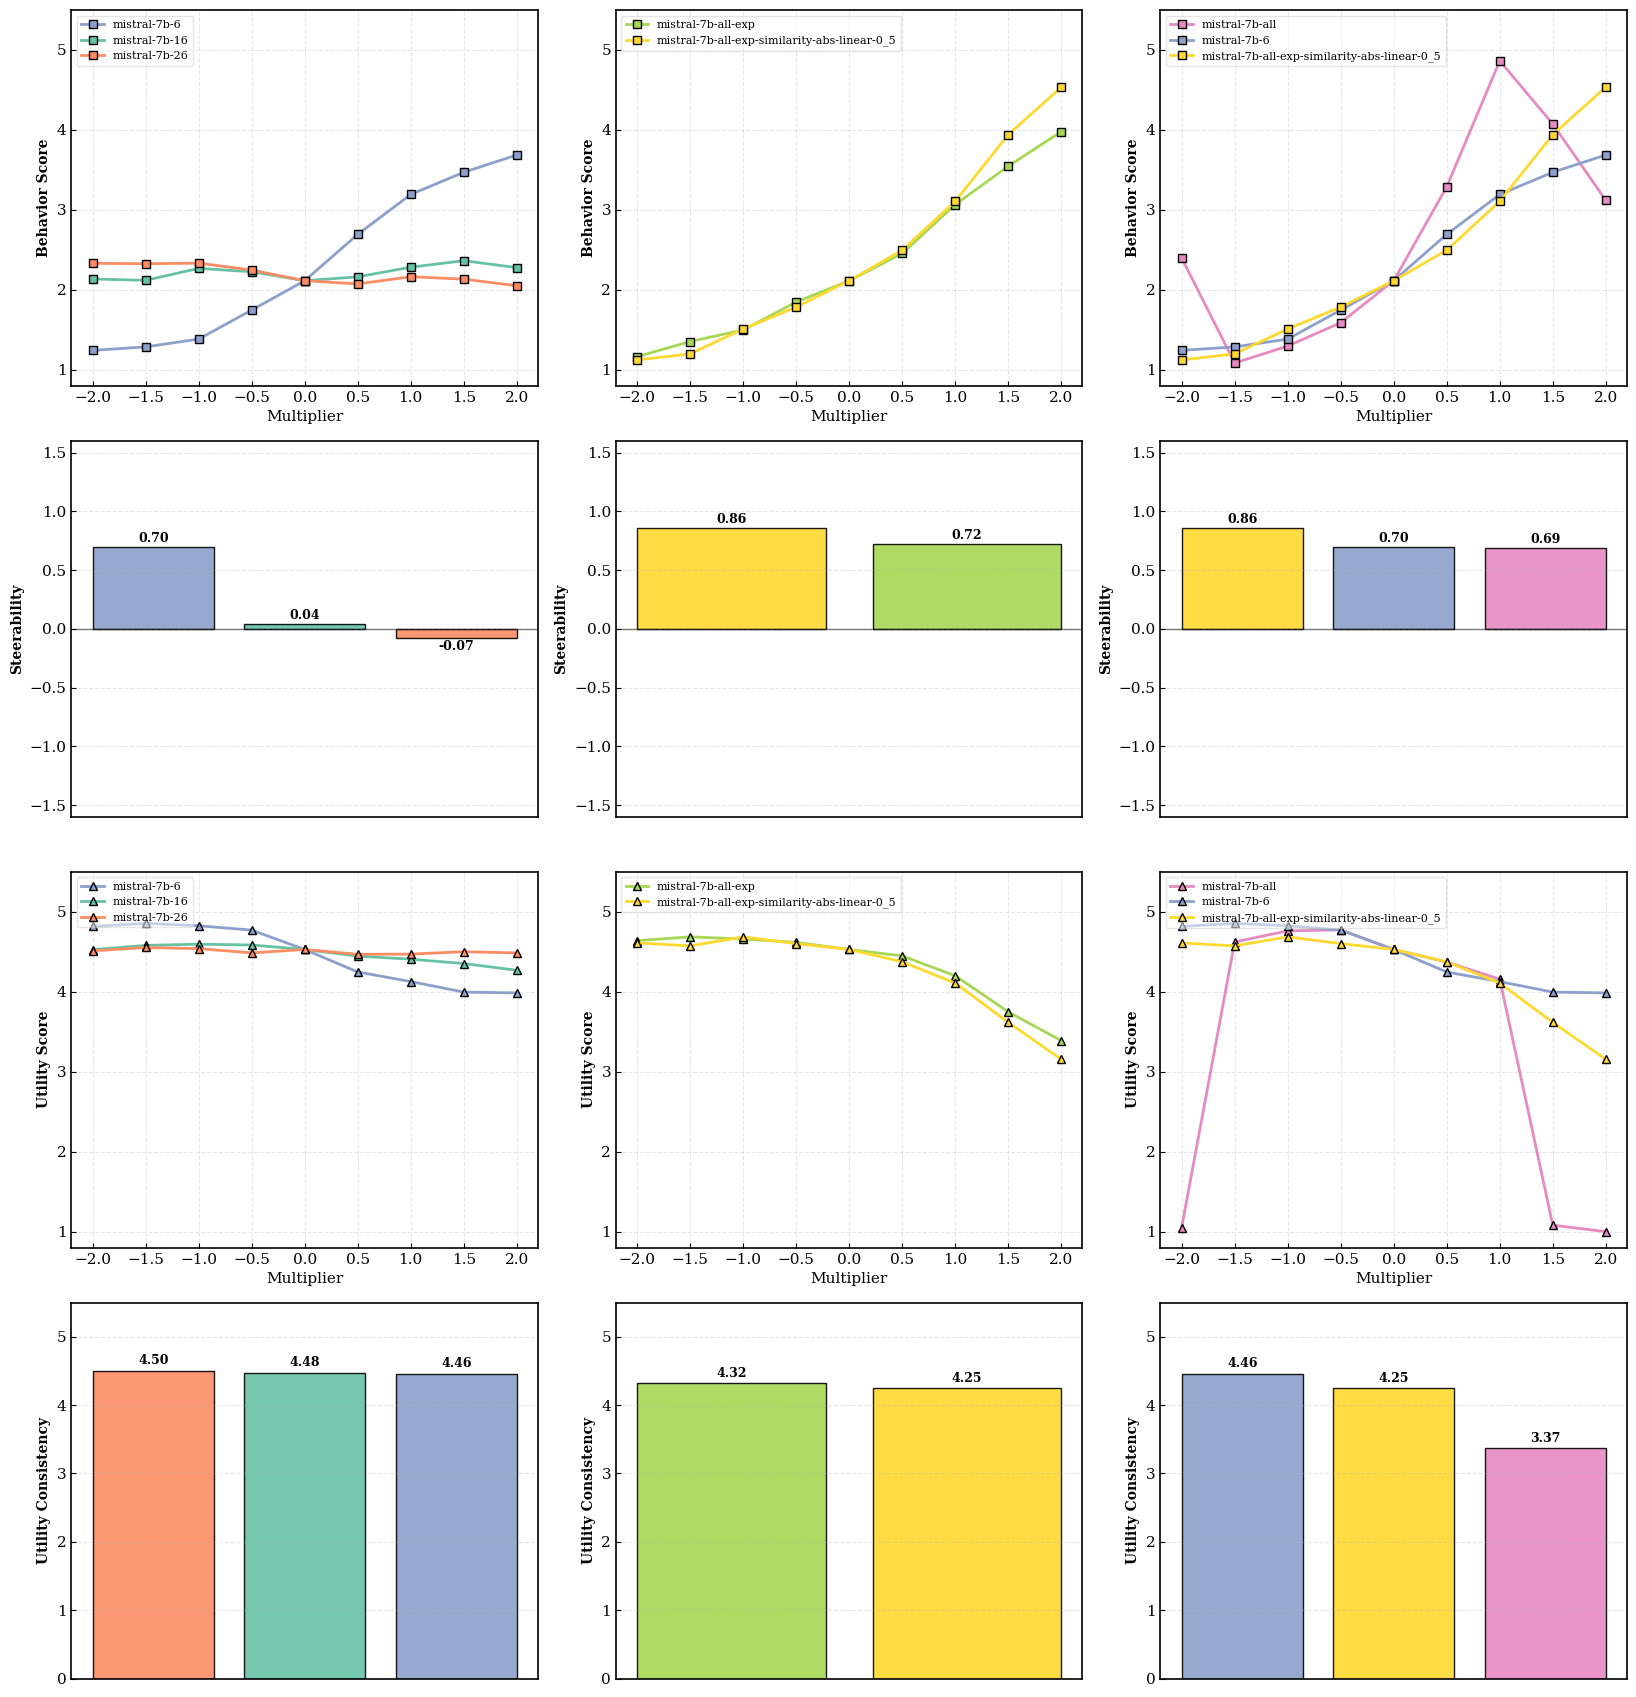

In [107]:
data_mistral = {
    "Single Layer Ablation": {
        "mistral-7b-6": {
            "behavior": {-2.0: 1.2446808510638299, -1.5: 1.2881355932203389, -1.0: 1.3854748603351956, -0.5: 1.7486631016042782, 0.0: 2.1155778894472363, 0.5: 2.6954314720812182, 1.0: 3.193877551020408, 1.5: 3.471502590673575, 2.0: 3.687179487179487},
            "utility": {-2.0: 4.815384615384615, -1.5: 4.8542713567839195, -1.0: 4.824120603015075, -0.5: 4.77, 0.0: 4.527638190954774, 0.5: 4.2462311557788945, 1.0: 4.126262626262626, 1.5: 3.994871794871795, 2.0: 3.984771573604061}
        },
        "mistral-7b-16": {
            "behavior": {-2.0: 2.1373626373626373, -1.5: 2.120218579234973, -1.0: 2.2698412698412698, -0.5: 2.227777777777778, 0.0: 2.1155778894472363, 0.5: 2.164102564102564, 1.0: 2.284263959390863, 1.5: 2.365979381443299, 2.0: 2.279187817258883},
            "utility": {-2.0: 4.525252525252525, -1.5: 4.5786802030456855, -1.0: 4.593908629441624, -0.5: 4.583756345177665, 0.0: 4.527638190954774, 0.5: 4.444444444444445, 1.0: 4.406091370558376, 1.5: 4.351758793969849, 2.0: 4.267676767676767}
        },
        "mistral-7b-26": {
            "behavior": {-2.0: 2.3333333333333335, -1.5: 2.3278688524590163, -1.0: 2.3351648351648353, -0.5: 2.248618784530387, 0.0: 2.1155778894472363, 0.5: 2.0757575757575757, 1.0: 2.1649484536082473, 1.5: 2.1354166666666665, 2.0: 2.051813471502591},
            "utility": {-2.0: 4.51, -1.5: 4.552763819095477, -1.0: 4.538071065989848, -0.5: 4.485, 0.0: 4.527638190954774, 0.5: 4.467336683417085, 1.0: 4.46969696969697, 1.5: 4.5, 2.0: 4.484848484848484}
        }
    },
    "k1 Ablation": {
        "mistral-7b-all-exp": {
            "behavior": {-2.0: 1.1657754010695187, -1.5: 1.355191256830601, -1.0: 1.5, -0.5: 1.8486486486486486, 0.0: 2.1155778894472363, 0.5: 2.4568527918781724, 1.0: 3.0677083333333335, 1.5: 3.5473684210526315, 2.0: 3.9797979797979797},
            "utility": {-2.0: 4.63819095477387, -1.5: 4.685279187817259, -1.0: 4.658291457286432, -0.5: 4.616161616161616, 0.0: 4.527638190954774, 0.5: 4.447236180904523, 1.0: 4.198979591836735, 1.5: 3.7474747474747474, 2.0: 3.387434554973822}
        },
        "mistral-7b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.125, -1.5: 1.201086956521739, -1.0: 1.511764705882353, -0.5: 1.786096256684492, 0.0: 2.1155778894472363, 0.5: 2.4974874371859297, 1.0: 3.1082474226804124, 1.5: 3.9427083333333335, 2.0: 4.536082474226804},
            "utility": {-2.0: 4.609375, -1.5: 4.57286432160804, -1.0: 4.685, -0.5: 4.601010101010101, 0.0: 4.527638190954774, 0.5: 4.373737373737374, 1.0: 4.107142857142857, 1.5: 3.6161616161616164, 2.0: 3.1538461538461537}
        }
    },
    "Multi Layer Ablation": {
        "mistral-7b-all": {
            "behavior": {-2.0: 2.4010695187165774, -1.5: 1.0869565217391304, -1.0: 1.298342541436464, -0.5: 1.590643274853801, 0.0: 2.1155778894472363, 0.5: 3.2908163265306123, 1.0: 4.864321608040201, 1.5: 4.074468085106383, 2.0: 3.120218579234973},
            "utility": {-2.0: 1.050251256281407, -1.5: 4.621212121212121, -1.0: 4.76, -0.5: 4.7727272727272725, 0.0: 4.527638190954774, 0.5: 4.371134020618556, 1.0: 4.156565656565657, 1.5: 1.0808080808080809, 2.0: 1.0}
        },
        "mistral-7b-6": {
            "behavior": {-2.0: 1.2446808510638299, -1.5: 1.2881355932203389, -1.0: 1.3854748603351956, -0.5: 1.7486631016042782, 0.0: 2.1155778894472363, 0.5: 2.6954314720812182, 1.0: 3.193877551020408, 1.5: 3.471502590673575, 2.0: 3.687179487179487},
            "utility": {-2.0: 4.815384615384615, -1.5: 4.8542713567839195, -1.0: 4.824120603015075, -0.5: 4.77, 0.0: 4.527638190954774, 0.5: 4.2462311557788945, 1.0: 4.126262626262626, 1.5: 3.994871794871795, 2.0: 3.984771573604061}
        },
        "mistral-7b-all-exp-similarity-abs-linear-0_5": {
            "behavior": {-2.0: 1.125, -1.5: 1.201086956521739, -1.0: 1.511764705882353, -0.5: 1.786096256684492, 0.0: 2.1155778894472363, 0.5: 2.4974874371859297, 1.0: 3.1082474226804124, 1.5: 3.9427083333333335, 2.0: 4.536082474226804},
            "utility": {-2.0: 4.609375, -1.5: 4.57286432160804, -1.0: 4.685, -0.5: 4.601010101010101, 0.0: 4.527638190954774, 0.5: 4.373737373737374, 1.0: 4.107142857142857, 1.5: 3.6161616161616164, 2.0: 3.1538461538461537}
        }
    }
}
plot_bipo_data(data_mistral)